reference data: using ../1/advection_c40_data.npz
Reference loaded:
  x: (256,) range: 0.0 to 6.283185307179586
  t: (600,) range: 0.0 to 1.0
  u_ref: (600, 256)
  u_ref min/max: -0.9999999956768499 0.999999999999663
Deterministic SQP: using ../1/theta_transport_c40_stosqp_fixed_damp.npy
Deterministic SQP: theta size = 1981
Sto-SQP: using ../1/theta_transport_c60_stosqp_fixed_damp.npy
Sto-SQP: theta size = 1981
ALM: using ../traditional_alm_transport_best.npy
ALM: theta size = 1981
Adam: using ../1/transport_c40_adam_50x4_best_theta.npy
Adam: theta size = 7851

================ FULL-GRID METRICS ================
Sto-SQP              MSE = 2.672717e-07, relL2 = 7.311081e-04
Deterministic SQP    MSE = 2.655593e-07, relL2 = 7.287623e-04
ALM                  MSE = 5.474142e-05, relL2 = 1.046317e-02
Adam                 MSE = 2.768472e-01, relL2 = 7.440895e-01

Figure metrics:
Sto-SQP              MSE=2.672717e-07, relL2=7.311081e-04
Deterministic SQP    MSE=2.655593e-07, relL2=7.287623e-04

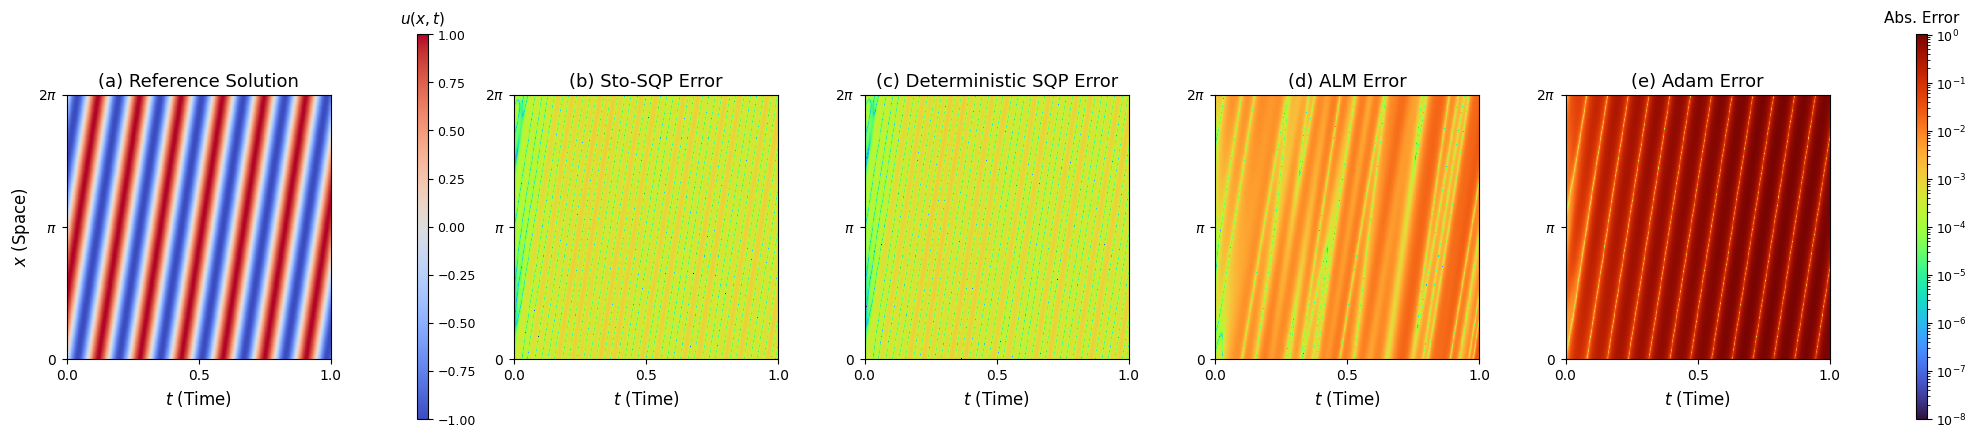

In [4]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ============================================================
# USER SETTINGS
# ============================================================

# Run this script from:
#   main/heatmaps/
#
# Reference transport data is probably in:
#   main/1/advection_c40_data.npz
# or
#   main/advection_c40_data.npz

REF_CANDIDATES = [
    "../1/advection_c40_data.npz",
    "../advection_c40_data.npz",
    "../1/advection_wave_data.npz",
    "../advection_wave_data.npz",
]

# ------------------------------------------------------------
# Model files
# ------------------------------------------------------------
# You said:
# deterministic SQP:
#   theta_transport_c40_stosqp_fixed_damp.npy
#
# Sto-SQP:
#   theta_transport_c60_stosqp_fixed_damp.npy
# but name says c60 even though it is actually c40.

DET_SQP_CANDIDATES = [
    "../1/theta_transport_c40_stosqp_fixed_damp.npy",
    "../theta_transport_c40_stosqp_fixed_damp.npy",
]

STO_SQP_CANDIDATES = [
    "../1/theta_transport_c60_stosqp_fixed_damp.npy",
    "../theta_transport_c60_stosqp_fixed_damp.npy",
]

ALM_CANDIDATES = [
    "../1/traditional_alm_transport_best.npy",
    "../traditional_alm_transport_best.npy",
    "../1/traditional_alm_transport_final.npy",
    "../traditional_alm_transport_final.npy",
]

ADAM_CANDIDATES = [
    "../1/transport_c40_adam_50x4_best_theta.npy",
    "../transport_c40_adam_50x4_best_theta.npy",
    "../1/transport_c40_adam_50x4_theta.npy",
    "../transport_c40_adam_50x4_theta.npy",
]

SAVE_PREFIX = "transport_reference_plus_4_errors"

# ------------------------------------------------------------
# Domain
# ------------------------------------------------------------
T_FINAL = 1.0
L_DOMAIN = 2.0 * np.pi
C_ADV = 40.0

# ------------------------------------------------------------
# Architecture
# ------------------------------------------------------------
SQP_LAYER_SIZES  = [2, 30, 30, 30, 1]
ALM_LAYER_SIZES  = [2, 30, 30, 30, 1]
ADAM_LAYER_SIZES = [2, 50, 50, 50, 50, 1]

SQP_ACTIVATION  = "tanh"
ALM_ACTIVATION  = "tanh"
ADAM_ACTIVATION = "tanh"

NORMALIZE_INPUT = True

# ------------------------------------------------------------
# Colormaps / color scale
# ------------------------------------------------------------
REF_CMAP = "coolwarm"
ERR_CMAP = "turbo"

ERR_VMIN = 1e-8
FIG_DPI = 300


# ============================================================
# FILE HELPERS
# ============================================================

def find_existing_file(candidates, name):
    for p in candidates:
        if Path(p).exists():
            print(f"{name}: using {p}")
            return p

    raise FileNotFoundError(
        f"Could not find {name}. Tried:\n" + "\n".join(candidates)
    )


def load_theta(candidates, name):
    path = find_existing_file(candidates, name)
    theta = np.load(path, allow_pickle=True)
    theta = np.asarray(theta, dtype=np.float64).reshape(-1)

    print(f"{name}: theta size = {theta.size}")
    return path, theta


# ============================================================
# REFERENCE DATA
# ============================================================

def generate_transport_dataset(T=T_FINAL, L=L_DOMAIN, c=C_ADV, n_t=600, n_x=256):
    t = np.linspace(0.0, T, n_t)
    x = np.linspace(0.0, L, n_x)

    TT, XX = np.meshgrid(t, x, indexing="ij")
    u_ref = np.sin((XX - c * TT) % L)

    return x, t, u_ref


def load_reference():
    path = find_existing_file(REF_CANDIDATES, "reference data")
    data = np.load(path, allow_pickle=True)

    if "u_ref" in data:
        u_ref = np.asarray(data["u_ref"], dtype=np.float64)
    elif "usol" in data:
        u_ref = np.asarray(data["usol"], dtype=np.float64)
    else:
        raise KeyError("Reference npz must contain 'u_ref' or 'usol'.")

    if "x_star" in data:
        x = np.asarray(data["x_star"], dtype=np.float64).squeeze()
    elif "x" in data:
        x = np.asarray(data["x"], dtype=np.float64).squeeze()
    else:
        raise KeyError("Reference npz must contain 'x_star' or 'x'.")

    if "t_star" in data:
        t = np.asarray(data["t_star"], dtype=np.float64).squeeze()
    elif "t" in data:
        t = np.asarray(data["t"], dtype=np.float64).squeeze()
    else:
        raise KeyError("Reference npz must contain 't_star' or 't'.")

    # Ensure shape is (nt, nx)
    if u_ref.shape == (len(x), len(t)):
        u_ref = u_ref.T

    if u_ref.shape != (len(t), len(x)):
        raise ValueError(
            f"Reference shape mismatch: u_ref.shape={u_ref.shape}, "
            f"expected {(len(t), len(x))}"
        )

    print("Reference loaded:")
    print("  x:", x.shape, "range:", float(x[0]), "to", float(x[-1]))
    print("  t:", t.shape, "range:", float(t[0]), "to", float(t[-1]))
    print("  u_ref:", u_ref.shape)
    print("  u_ref min/max:", float(np.min(u_ref)), float(np.max(u_ref)))

    return x, t, u_ref


# ============================================================
# MLP HELPERS
# ============================================================

def normalize_xt(X):
    """
    Input X has columns [x, t].
    Same normalization as your transport SQP/ALM scripts:
        x -> 2*x/L - 1
        t -> 2*t/T - 1
    """
    x = X[:, 0:1]
    t = X[:, 1:2]

    x_n = 2.0 * x / L_DOMAIN - 1.0
    t_n = 2.0 * t / T_FINAL - 1.0

    return np.concatenate([x_n, t_n], axis=1)


def activate(z, name):
    if name == "tanh":
        return np.tanh(z)
    elif name == "silu":
        return z / (1.0 + np.exp(-z))
    elif name == "relu":
        return np.maximum(z, 0.0)
    elif name == "gelu":
        return 0.5 * z * (
            1.0 + np.tanh(np.sqrt(2.0 / np.pi) * (z + 0.044715 * z ** 3))
        )
    else:
        raise ValueError(f"Unsupported activation: {name}")


def unflatten_theta(theta, layer_sizes):
    theta = np.asarray(theta, dtype=np.float64).reshape(-1)
    params = []
    idx = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n

        W = theta[idx:idx + w_size].reshape(m, n)
        idx += w_size

        b = theta[idx:idx + b_size].reshape(1, n)
        idx += b_size

        params.append((W, b))

    if idx != theta.size:
        raise ValueError(
            f"Did not consume all theta entries: used {idx}, total {theta.size}.\n"
            f"Layer sizes = {layer_sizes}"
        )

    return params


def mlp_predict(theta, layer_sizes, X, activation="tanh", normalize_input=True):
    params = unflatten_theta(theta, layer_sizes)

    H = normalize_xt(X) if normalize_input else X.copy()

    for i, (W, b) in enumerate(params):
        H = H @ W + b
        if i < len(params) - 1:
            H = activate(H, activation)

    return H[:, 0]


def predict_on_grid(theta, layer_sizes, x, t, activation="tanh", normalize_input=True):
    """
    Returns u_pred with shape (nt, nx).
    Input order is [x,t].
    """
    TT, XX = np.meshgrid(t, x, indexing="ij")

    X_eval = np.stack(
        [XX.reshape(-1), TT.reshape(-1)],
        axis=1,
    )

    u_pred = mlp_predict(
        theta=theta,
        layer_sizes=layer_sizes,
        X=X_eval,
        activation=activation,
        normalize_input=normalize_input,
    )

    return u_pred.reshape(len(t), len(x))


def mse(a, b):
    return float(np.mean((a - b) ** 2))


def rel_l2(a, b):
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-12))


# ============================================================
# PLOTTING
# ============================================================

def make_figure(x, t, u_ref, pred_dict, err_dict, metric_dict):
    # --------------------------------------------------------
    # Shared color scales
    # --------------------------------------------------------
    ref_vabs = np.max(np.abs(u_ref))
    ref_vmin = -ref_vabs
    ref_vmax =  ref_vabs

    overall_err_max = max(float(np.max(v)) for v in err_dict.values())
    err_vmax = max(1.0, overall_err_max)

    extent = [t[0], t[-1], x[0], x[-1]]

    # --------------------------------------------------------
    # Figure layout:
    # [ref] [ref cbar] [sto] [det] [alm] [adam] [err cbar]
    # --------------------------------------------------------
    fig = plt.figure(figsize=(24, 5.0))

    gs = fig.add_gridspec(
        1,
        7,
        width_ratios=[1.0, 0.04, 1.0, 1.0, 1.0, 1.0, 0.04],
        wspace=0.45,
    )

    ax_ref  = fig.add_subplot(gs[0, 0])
    cax_ref = fig.add_subplot(gs[0, 1])

    ax_sto  = fig.add_subplot(gs[0, 2])
    ax_det  = fig.add_subplot(gs[0, 3])
    ax_alm  = fig.add_subplot(gs[0, 4])
    ax_adam = fig.add_subplot(gs[0, 5])

    cax_err = fig.add_subplot(gs[0, 6])

    # --------------------------------------------------------
    # Reference solution
    # --------------------------------------------------------
    im_ref = ax_ref.imshow(
        u_ref.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=REF_CMAP,
        vmin=ref_vmin,
        vmax=ref_vmax,
        interpolation="nearest",
    )

    cb_ref = fig.colorbar(im_ref, cax=cax_ref)
    cb_ref.ax.set_title(r"$u(x,t)$", fontsize=11, pad=8)
    cb_ref.ax.tick_params(labelsize=9)

    ax_ref.set_title("(a) Reference Solution", fontsize=13)

    # --------------------------------------------------------
    # Error heatmaps
    # --------------------------------------------------------
    err_norm = LogNorm(vmin=ERR_VMIN, vmax=err_vmax)

    panels = [
        (ax_sto,  "(b) Sto-SQP Error",            err_dict["Sto-SQP"]),
        (ax_det,  "(c) Deterministic SQP Error",  err_dict["Deterministic SQP"]),
        (ax_alm,  "(d) ALM Error",                err_dict["ALM"]),
        (ax_adam, "(e) Adam Error",               err_dict["Adam"]),
    ]

    last_im = None

    for ax, title, err in panels:
        err_plot = np.maximum(err.T, ERR_VMIN)

        last_im = ax.imshow(
            err_plot,
            origin="lower",
            aspect="auto",
            extent=extent,
            cmap=ERR_CMAP,
            norm=err_norm,
            interpolation="nearest",
        )

        ax.set_title(title, fontsize=13)

    cb_err = fig.colorbar(last_im, cax=cax_err)
    cb_err.ax.set_title("Abs. Error", fontsize=11, pad=8)
    cb_err.ax.tick_params(labelsize=9)

    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------
    all_axes = [ax_ref, ax_sto, ax_det, ax_alm, ax_adam]

    for ax in all_axes:
        ax.set_xlabel(r"$t$ (Time)", fontsize=12)

        ax.set_xlim(t[0], t[-1])
        ax.set_ylim(x[0], x[-1])

        ax.set_xticks([0.0, 0.5, 1.0])
        ax.set_yticks([0.0, np.pi, 2.0 * np.pi])
        ax.set_yticklabels([r"$0$", r"$\pi$", r"$2\pi$"])

        ax.tick_params(labelsize=10)
        ax.set_box_aspect(1)

    # Only one y-label for the row
    ax_ref.set_ylabel(r"$x$ (Space)", fontsize=12)

    for ax in [ax_sto, ax_det, ax_alm, ax_adam]:
        ax.set_ylabel("")

    # --------------------------------------------------------
    # Print metrics
    # --------------------------------------------------------
    print("\nFigure metrics:")
    for name in ["Sto-SQP", "Deterministic SQP", "ALM", "Adam"]:
        print(
            f"{name:20s} MSE={metric_dict[name]['mse']:.6e}, "
            f"relL2={metric_dict[name]['relL2']:.6e}"
        )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    fig.savefig(f"{SAVE_PREFIX}.png", dpi=FIG_DPI, bbox_inches="tight")
    fig.savefig(f"{SAVE_PREFIX}.pdf", bbox_inches="tight")

    print(f"\nSaved figure -> {SAVE_PREFIX}.png")
    print(f"Saved figure -> {SAVE_PREFIX}.pdf")

    plt.show()


# ============================================================
# MAIN
# ============================================================

def main():
    # --------------------------------------------------------
    # Load reference
    # --------------------------------------------------------
    x, t, u_ref = load_reference()

    # --------------------------------------------------------
    # Load theta files
    # --------------------------------------------------------
    det_path, theta_det = load_theta(DET_SQP_CANDIDATES, "Deterministic SQP")
    sto_path, theta_sto = load_theta(STO_SQP_CANDIDATES, "Sto-SQP")
    alm_path, theta_alm = load_theta(ALM_CANDIDATES, "ALM")
    adam_path, theta_adam = load_theta(ADAM_CANDIDATES, "Adam")

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------
    u_det = predict_on_grid(
        theta_det,
        SQP_LAYER_SIZES,
        x,
        t,
        activation=SQP_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    u_sto = predict_on_grid(
        theta_sto,
        SQP_LAYER_SIZES,
        x,
        t,
        activation=SQP_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    u_alm = predict_on_grid(
        theta_alm,
        ALM_LAYER_SIZES,
        x,
        t,
        activation=ALM_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    u_adam = predict_on_grid(
        theta_adam,
        ADAM_LAYER_SIZES,
        x,
        t,
        activation=ADAM_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    # --------------------------------------------------------
    # Errors
    # --------------------------------------------------------
    err_sto  = np.abs(u_sto  - u_ref)
    err_det  = np.abs(u_det  - u_ref)
    err_alm  = np.abs(u_alm  - u_ref)
    err_adam = np.abs(u_adam - u_ref)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------
    metric_dict = {
        "Sto-SQP": {
            "mse": mse(u_sto, u_ref),
            "relL2": rel_l2(u_sto, u_ref),
        },
        "Deterministic SQP": {
            "mse": mse(u_det, u_ref),
            "relL2": rel_l2(u_det, u_ref),
        },
        "ALM": {
            "mse": mse(u_alm, u_ref),
            "relL2": rel_l2(u_alm, u_ref),
        },
        "Adam": {
            "mse": mse(u_adam, u_ref),
            "relL2": rel_l2(u_adam, u_ref),
        },
    }

    print("\n================ FULL-GRID METRICS ================")
    for name, m in metric_dict.items():
        print(f"{name:20s} MSE = {m['mse']:.6e}, relL2 = {m['relL2']:.6e}")

    pred_dict = {
        "Sto-SQP": u_sto,
        "Deterministic SQP": u_det,
        "ALM": u_alm,
        "Adam": u_adam,
    }

    err_dict = {
        "Sto-SQP": err_sto,
        "Deterministic SQP": err_det,
        "ALM": err_alm,
        "Adam": err_adam,
    }

    make_figure(x, t, u_ref, pred_dict, err_dict, metric_dict)


if __name__ == "__main__":
    main()

reference data: using ../1/advection_c40_data.npz
Reference loaded:
  x: (256,) range: 0.0 to 6.283185307179586
  t: (600,) range: 0.0 to 1.0
  u_ref: (600, 256)
  u_ref min/max: -0.9999999956768499 0.999999999999663
ALM: using ../traditional_alm_transport_best.npy
ALM: theta size = 1981
Adam: using ../1/transport_c40_adam_50x4_best_theta.npy
Adam: theta size = 7851
ALM:
  MSE   = 5.4741419675617835e-05
  relL2 = 0.010463166834039962
Adam:
  MSE   = 0.2768471755573289
  relL2 = 0.7440894904035488


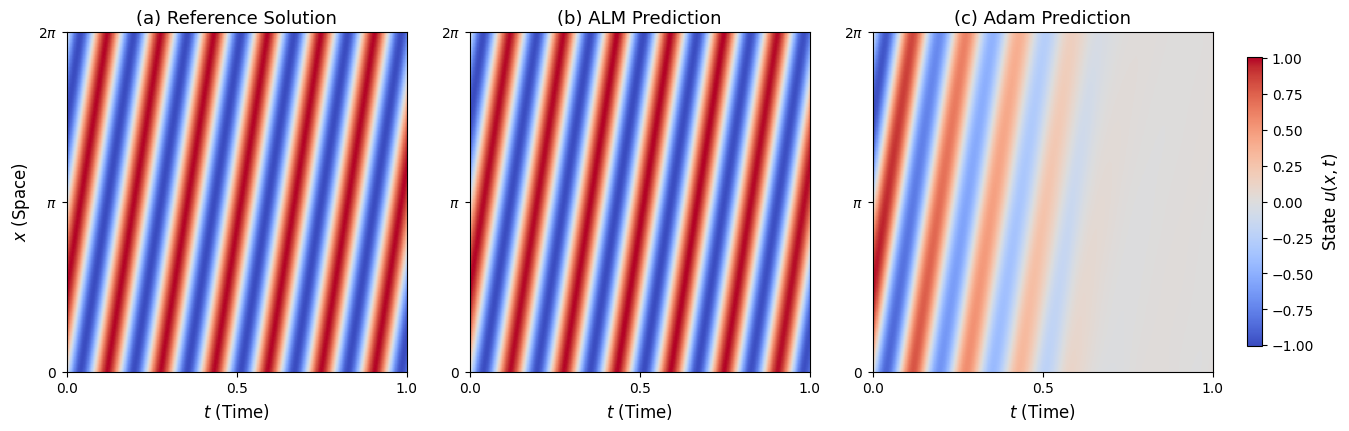

In [5]:
# ============================================================
# Transport prediction heatmaps: Exact vs ALM vs Adam
# Run this after the previous transport heatmap code cell
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load reference
# ------------------------------------------------------------
x, t, u_ref = load_reference()

# ------------------------------------------------------------
# Load ALM and Adam theta
# ------------------------------------------------------------
alm_path, theta_alm = load_theta(ALM_CANDIDATES, "ALM")
adam_path, theta_adam = load_theta(ADAM_CANDIDATES, "Adam")

# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------
u_alm = predict_on_grid(
    theta_alm,
    ALM_LAYER_SIZES,
    x,
    t,
    activation=ALM_ACTIVATION,
    normalize_input=NORMALIZE_INPUT,
)

u_adam = predict_on_grid(
    theta_adam,
    ADAM_LAYER_SIZES,
    x,
    t,
    activation=ADAM_ACTIVATION,
    normalize_input=NORMALIZE_INPUT,
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
print("ALM:")
print("  MSE   =", mse(u_alm, u_ref))
print("  relL2 =", rel_l2(u_alm, u_ref))

print("Adam:")
print("  MSE   =", mse(u_adam, u_ref))
print("  relL2 =", rel_l2(u_adam, u_ref))

# ------------------------------------------------------------
# Shared state color scale
# ------------------------------------------------------------
vabs = max(
    np.max(np.abs(u_ref)),
    np.max(np.abs(u_alm)),
    np.max(np.abs(u_adam)),
)

vmin = -vabs
vmax =  vabs

extent = [t[0], t[-1], x[0], x[-1]]

# ------------------------------------------------------------
# Plot exact / ALM / Adam predictions
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), constrained_layout=True)

panels = [
    (u_ref,  "(a) Reference Solution"),
    (u_alm,  "(b) ALM Prediction"),
    (u_adam, "(c) Adam Prediction"),
]

last_im = None

for ax, (arr, title) in zip(axes, panels):
    last_im = ax.imshow(
        arr.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )

    ax.set_title(title, fontsize=13)
    ax.set_xlabel(r"$t$ (Time)", fontsize=12)
    ax.set_xlim(t[0], t[-1])
    ax.set_ylim(x[0], x[-1])

    ax.set_xticks([0.0, 0.5, 1.0])
    ax.set_yticks([0.0, np.pi, 2.0 * np.pi])
    ax.set_yticklabels([r"$0$", r"$\pi$", r"$2\pi$"])

    ax.tick_params(labelsize=10)
    ax.set_box_aspect(1)

axes[0].set_ylabel(r"$x$ (Space)", fontsize=12)
for ax in axes[1:]:
    ax.set_ylabel("")

cbar = fig.colorbar(last_im, ax=axes, shrink=0.85, pad=0.02)
cbar.set_label(r"State $u(x,t)$", fontsize=12)

fig.savefig("transport_alm_adam_prediction_heatmaps.png", dpi=300, bbox_inches="tight")
fig.savefig("transport_alm_adam_prediction_heatmaps.pdf", bbox_inches="tight")

plt.show()

Reference shape: (600, 256)
Loaded Adam theta: ../1/transport_c40_adam_50x4_best_theta.npy
Theta size: (7851,)
Adam MSE   = 2.768472e-01
Adam relL2 = 7.440895e-01
Max abs err = 1.022690e+00
Min abs err = 2.211225e-06


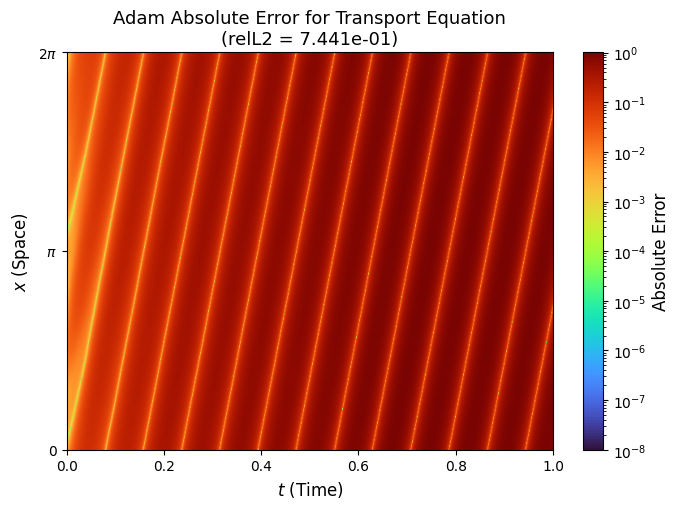

Saved figure -> transport_adam_error_only.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ============================================================
# Settings
# ============================================================
ADAM_THETA_PATH = "../1/transport_c40_adam_50x4_best_theta.npy"

# if you want final instead, use:
# ADAM_THETA_PATH = "transport_c40_adam_50x4_theta.npy"

T = 1.0
L = 2.0 * np.pi
C = 40.0
N_T = 600
N_X = 256

WIDTH = 50
NUM_HIDDEN = 4
ACTIVATION = "tanh"
NORMALIZE_INPUT = True

SAVE_NAME = "transport_adam_error_only.png"

# ============================================================
# Exact/reference solution
# ============================================================
t_np = np.linspace(0.0, T, N_T)
x_np = np.linspace(0.0, L, N_X)

TT, XX = np.meshgrid(t_np, x_np, indexing="ij")
u_ref = np.sin((XX - C * TT) % L)

print("Reference shape:", u_ref.shape)

# ============================================================
# Network helpers
# architecture: [2] + [WIDTH]*NUM_HIDDEN + [1]
# ============================================================
layer_sizes = [2] + [WIDTH] * NUM_HIDDEN + [1]

def normalize_xt(X):
    x = X[:, 0:1]
    t = X[:, 1:2]

    x_n = 2.0 * (x - 0.0) / (L - 0.0) - 1.0
    t_n = 2.0 * (t - 0.0) / (T - 0.0) - 1.0
    return np.concatenate([x_n, t_n], axis=1)

def unflatten_params(theta, layer_sizes):
    params = []
    idx = 0
    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n

        W = theta[idx:idx + w_size].reshape(m, n)
        idx += w_size

        b = theta[idx:idx + b_size].reshape(1, n)
        idx += b_size

        params.append((W, b))

    if idx != len(theta):
        raise ValueError(f"Did not consume all theta entries: used {idx}, total {len(theta)}")

    return params

def activate(z):
    if ACTIVATION == "tanh":
        return np.tanh(z)
    elif ACTIVATION == "silu":
        return z / (1.0 + np.exp(-z))
    else:
        raise ValueError("Unsupported activation")

def predict_u(theta, X):
    params = unflatten_params(theta, layer_sizes)

    if NORMALIZE_INPUT:
        h = normalize_xt(X)
    else:
        h = X.copy()

    for i, (W, b) in enumerate(params):
        h = h @ W + b
        if i < len(params) - 1:
            h = activate(h)

    return h[:, 0]

# ============================================================
# Load Adam theta
# ============================================================
theta_adam = np.load(ADAM_THETA_PATH)
print("Loaded Adam theta:", ADAM_THETA_PATH)
print("Theta size:", theta_adam.shape)

# ============================================================
# Predict on full grid
# ============================================================
X_grid = np.stack([XX.reshape(-1), TT.reshape(-1)], axis=1)
u_pred = predict_u(theta_adam, X_grid).reshape(N_T, N_X)

# ============================================================
# Metrics
# ============================================================
abs_err = np.abs(u_pred - u_ref)
mse = np.mean((u_pred - u_ref) ** 2)
rel_l2 = np.sqrt(np.mean((u_pred - u_ref) ** 2) / (np.mean(u_ref ** 2) + 1e-30))

print(f"Adam MSE   = {mse:.6e}")
print(f"Adam relL2 = {rel_l2:.6e}")
print(f"Max abs err = {abs_err.max():.6e}")
print(f"Min abs err = {abs_err.min():.6e}")

# ============================================================
# Plot: Adam absolute error only
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5.2))

im = ax.imshow(
    abs_err.T,
    origin="lower",
    aspect="auto",
    extent=[t_np[0], t_np[-1], x_np[0], x_np[-1]],
    cmap="turbo",
    norm=LogNorm(vmin=1e-8, vmax=max(1.0, abs_err.max())),
)

cb = fig.colorbar(im, ax=ax)
cb.set_label("Absolute Error", fontsize=12)

ax.set_xlabel(r"$t$ (Time)", fontsize=12)
ax.set_ylabel(r"$x$ (Space)", fontsize=12)
ax.set_title(
    rf"Adam Absolute Error for Transport Equation" "\n"
    rf"(relL2 = {rel_l2:.3e})",
    fontsize=13
)

ax.set_yticks([0, np.pi, 2*np.pi])
ax.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])

plt.tight_layout()
plt.savefig(SAVE_NAME, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure -> {SAVE_NAME}")

reference data: using ../1/advection_c40_data.npz
Reference loaded:
  x: (256,) range: 0.0 to 6.283185307179586
  t: (600,) range: 0.0 to 1.0
  u_ref: (600, 256)
Adam: using ../1/transport_c40_adam_50x4_best_theta.npy
Adam: theta size = 7851


Adam:
  MSE   = 0.2768471755573289
  relL2 = 0.7440894904035488


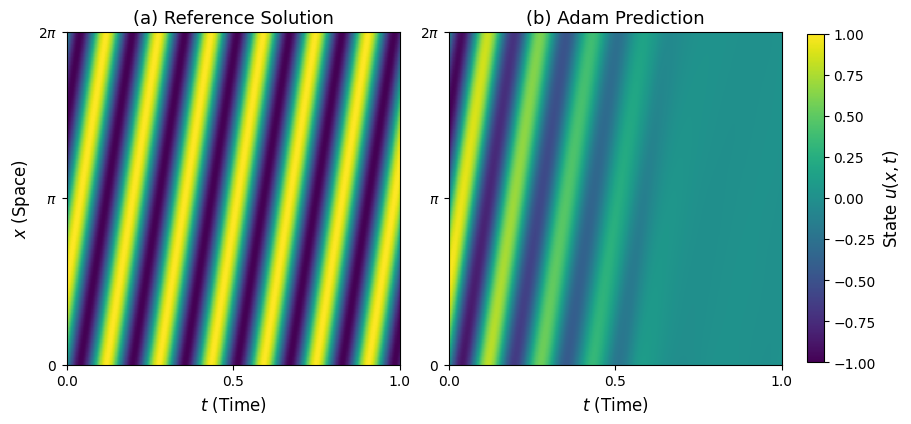

In [5]:
# ============================================================
# Transport prediction heatmaps: Reference vs Adam
# Self-contained version
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# SETTINGS
# ============================================================

REF_CANDIDATES = [
    "../1/advection_c40_data.npz",
    "../advection_c40_data.npz",
    "../1/advection_wave_data.npz",
    "../advection_wave_data.npz",
]

ADAM_CANDIDATES = [
    "../1/transport_c40_adam_50x4_best_theta.npy",
    "../transport_c40_adam_50x4_best_theta.npy",
    "../1/transport_c40_adam_50x4_theta.npy",
    "../transport_c40_adam_50x4_theta.npy",
]

T_FINAL = 1.0
L_DOMAIN = 2.0 * np.pi

ADAM_LAYER_SIZES = [2, 50, 50, 50, 50, 1]
ADAM_ACTIVATION = "tanh"
NORMALIZE_INPUT = True


# ============================================================
# HELPERS
# ============================================================

def find_existing_file(candidates, name):
    for p in candidates:
        if Path(p).exists():
            print(f"{name}: using {p}")
            return p

    raise FileNotFoundError(
        f"Could not find {name}. Tried:\n" + "\n".join(candidates)
    )


def load_theta(candidates, name):
    path = find_existing_file(candidates, name)
    theta = np.load(path, allow_pickle=True)
    theta = np.asarray(theta, dtype=np.float64).reshape(-1)
    print(f"{name}: theta size = {theta.size}")
    return path, theta


def load_reference():
    path = find_existing_file(REF_CANDIDATES, "reference data")
    data = np.load(path, allow_pickle=True)

    if "u_ref" in data:
        u_ref = np.asarray(data["u_ref"], dtype=np.float64)
    elif "usol" in data:
        u_ref = np.asarray(data["usol"], dtype=np.float64)
    else:
        raise KeyError("Reference npz must contain 'u_ref' or 'usol'.")

    if "x_star" in data:
        x = np.asarray(data["x_star"], dtype=np.float64).squeeze()
    elif "x" in data:
        x = np.asarray(data["x"], dtype=np.float64).squeeze()
    else:
        raise KeyError("Reference npz must contain 'x_star' or 'x'.")

    if "t_star" in data:
        t = np.asarray(data["t_star"], dtype=np.float64).squeeze()
    elif "t" in data:
        t = np.asarray(data["t"], dtype=np.float64).squeeze()
    else:
        raise KeyError("Reference npz must contain 't_star' or 't'.")

    # Ensure shape is (nt, nx)
    if u_ref.shape == (len(x), len(t)):
        u_ref = u_ref.T

    if u_ref.shape != (len(t), len(x)):
        raise ValueError(
            f"Reference shape mismatch: u_ref.shape={u_ref.shape}, "
            f"expected {(len(t), len(x))}"
        )

    print("Reference loaded:")
    print("  x:", x.shape, "range:", float(x[0]), "to", float(x[-1]))
    print("  t:", t.shape, "range:", float(t[0]), "to", float(t[-1]))
    print("  u_ref:", u_ref.shape)

    return x, t, u_ref


def normalize_xt(X):
    x = X[:, 0:1]
    t = X[:, 1:2]

    x_n = 2.0 * x / L_DOMAIN - 1.0
    t_n = 2.0 * t / T_FINAL - 1.0

    return np.concatenate([x_n, t_n], axis=1)


def activate(z, name):
    if name == "tanh":
        return np.tanh(z)
    elif name == "silu":
        return z / (1.0 + np.exp(-z))
    elif name == "relu":
        return np.maximum(z, 0.0)
    elif name == "gelu":
        return 0.5 * z * (
            1.0 + np.tanh(np.sqrt(2.0 / np.pi) * (z + 0.044715 * z ** 3))
        )
    else:
        raise ValueError(f"Unsupported activation: {name}")


def unflatten_theta(theta, layer_sizes):
    theta = np.asarray(theta, dtype=np.float64).reshape(-1)
    params = []
    idx = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n

        W = theta[idx:idx + w_size].reshape(m, n)
        idx += w_size

        b = theta[idx:idx + b_size].reshape(1, n)
        idx += b_size

        params.append((W, b))

    if idx != theta.size:
        raise ValueError(
            f"Did not consume all theta entries: used {idx}, total {theta.size}.\n"
            f"Layer sizes = {layer_sizes}"
        )

    return params


def mlp_predict(theta, layer_sizes, X, activation="tanh", normalize_input=True):
    params = unflatten_theta(theta, layer_sizes)

    H = normalize_xt(X) if normalize_input else X.copy()

    for i, (W, b) in enumerate(params):
        H = H @ W + b
        if i < len(params) - 1:
            H = activate(H, activation)

    return H[:, 0]


def predict_on_grid(theta, layer_sizes, x, t, activation="tanh", normalize_input=True):
    TT, XX = np.meshgrid(t, x, indexing="ij")

    X_eval = np.stack(
        [XX.reshape(-1), TT.reshape(-1)],
        axis=1,
    )

    u_pred = mlp_predict(
        theta=theta,
        layer_sizes=layer_sizes,
        X=X_eval,
        activation=activation,
        normalize_input=normalize_input,
    )

    return u_pred.reshape(len(t), len(x))


def mse(a, b):
    return float(np.mean((a - b) ** 2))


def rel_l2(a, b):
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-12))


# ============================================================
# LOAD + PREDICT
# ============================================================

x, t, u_ref = load_reference()

adam_path, theta_adam = load_theta(ADAM_CANDIDATES, "Adam")

u_adam = predict_on_grid(
    theta_adam,
    ADAM_LAYER_SIZES,
    x,
    t,
    activation=ADAM_ACTIVATION,
    normalize_input=NORMALIZE_INPUT,
)

print("Adam:")
print("  MSE   =", mse(u_adam, u_ref))
print("  relL2 =", rel_l2(u_adam, u_ref))


# ============================================================
# PLOT REFERENCE + ADAM ONLY
# ============================================================

vabs = max(
    np.max(np.abs(u_ref)),
    np.max(np.abs(u_adam)),
)

vmin = -vabs
vmax =  vabs

extent = [t[0], t[-1], x[0], x[-1]]

fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.2), constrained_layout=True)

panels = [
    (u_ref,  "(a) Reference Solution"),
    (u_adam, "(b) Adam Prediction"),
]

last_im = None

for ax, (arr, title) in zip(axes, panels):
    last_im = ax.imshow(
        arr.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )

    ax.set_title(title, fontsize=13)
    ax.set_xlabel(r"$t$ (Time)", fontsize=12)
    ax.set_xlim(t[0], t[-1])
    ax.set_ylim(x[0], x[-1])

    ax.set_xticks([0.0, 0.5, 1.0])
    ax.set_yticks([0.0, np.pi, 2.0 * np.pi])
    ax.set_yticklabels([r"$0$", r"$\pi$", r"$2\pi$"])

    ax.tick_params(labelsize=10)
    ax.set_box_aspect(1)

axes[0].set_ylabel(r"$x$ (Space)", fontsize=12)
axes[1].set_ylabel("")

cbar = fig.colorbar(last_im, ax=axes, shrink=0.85, pad=0.02)
cbar.set_label(r"State $u(x,t)$", fontsize=12)

fig.savefig("transport_reference_adam_prediction_heatmaps.png", dpi=300, bbox_inches="tight")
fig.savefig("transport_reference_adam_prediction_heatmaps.pdf", bbox_inches="tight")

plt.show()

In [ ]:
# ============================================================
# Transport heatmaps:
# Reference solution + Sto-SQP prediction + Deterministic SQP prediction
# No ALM, no Adam
# Same colormap for all three panels
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# USER SETTINGS
# ============================================================

# Run this from:
#   main/heatmaps/

REF_CANDIDATES = [
    "../1/advection_c40_data.npz",
    "../advection_c40_data.npz",
    "../1/advection_c60_data.npz",   # if your saved filename still says c60
    "../advection_c60_data.npz",
    "../1/advection_wave_data.npz",
    "../advection_wave_data.npz",
]

# Sto-SQP theta
STO_SQP_CANDIDATES = [
    "../1/theta_transport_c40_stosqp_jitter.npy",
    "../theta_transport_c40_stosqp_jitter.npy",
    "../1/theta_transport_c60_stosqp_fixed_damp.npy",
    "../theta_transport_c60_stosqp_fixed_damp.npy",
]

# Deterministic SQP theta
DET_SQP_CANDIDATES = [
    "../1/theta_transport_c40_deterministic_sqp.npy",
    "../theta_transport_c40_deterministic_sqp.npy",
    "../1/theta_transport_c40_stosqp_nojitter.npy",
    "../theta_transport_c40_stosqp_nojitter.npy",
    "../1/theta_transport_c60_deterministic.npy",
    "../theta_transport_c60_deterministic.npy",
]

SAVE_PREFIX = "transport_reference_sto_det_heatmaps"

# Domain
T_FINAL = 1.0
L_DOMAIN = 2.0 * np.pi
C_ADV = 40.0

# Network settings for SQP models
SQP_LAYER_SIZES = [2, 30, 30, 30, 1]
SQP_ACTIVATION = "tanh"
NORMALIZE_INPUT = True

# Plot style
REF_CMAP = "coolwarm"   # this is the "first color choice"
FIG_DPI = 300


# ============================================================
# FILE HELPERS
# ============================================================

def find_existing_file(candidates, name):
    for p in candidates:
        if Path(p).exists():
            print(f"{name}: using {p}")
            return p
    raise FileNotFoundError(
        f"Could not find {name}. Tried:\n" + "\n".join(candidates)
    )


def load_theta(candidates, name):
    path = find_existing_file(candidates, name)
    theta = np.load(path, allow_pickle=True)
    theta = np.asarray(theta, dtype=np.float64).reshape(-1)
    print(f"{name}: loaded {path}, theta size = {theta.size}")
    return path, theta


# ============================================================
# REFERENCE DATA
# ============================================================

def generate_transport_dataset(T=T_FINAL, L=L_DOMAIN, c=C_ADV, n_t=600, n_x=256):
    t = np.linspace(0.0, T, n_t)
    x = np.linspace(0.0, L, n_x)
    TT, XX = np.meshgrid(t, x, indexing="ij")
    u_ref = np.sin((XX - c * TT) % L)
    return x, t, u_ref


def load_reference():
    try:
        path = find_existing_file(REF_CANDIDATES, "Transport reference data")
    except FileNotFoundError:
        print("No reference file found. Generating exact transport reference data.")
        return generate_transport_dataset()

    data = np.load(path, allow_pickle=True)

    if "u_ref" in data:
        u_ref = np.asarray(data["u_ref"], dtype=np.float64)
    elif "usol" in data:
        u_ref = np.asarray(data["usol"], dtype=np.float64)
    else:
        raise KeyError("Reference npz must contain 'u_ref' or 'usol'.")

    if "x_star" in data:
        x = np.asarray(data["x_star"], dtype=np.float64).squeeze()
    elif "x" in data:
        x = np.asarray(data["x"], dtype=np.float64).squeeze()
    else:
        raise KeyError("Reference npz must contain 'x_star' or 'x'.")

    if "t_star" in data:
        t = np.asarray(data["t_star"], dtype=np.float64).squeeze()
    elif "t" in data:
        t = np.asarray(data["t"], dtype=np.float64).squeeze()
    else:
        raise KeyError("Reference npz must contain 't_star' or 't'.")

    # Make sure shape is (nt, nx)
    if u_ref.shape == (len(x), len(t)):
        u_ref = u_ref.T

    if u_ref.shape != (len(t), len(x)):
        raise ValueError(
            f"Reference shape mismatch: u_ref.shape={u_ref.shape}, "
            f"expected {(len(t), len(x))}"
        )

    print("Reference loaded:")
    print("  x:", x.shape, "range:", float(x[0]), "to", float(x[-1]))
    print("  t:", t.shape, "range:", float(t[0]), "to", float(t[-1]))
    print("  u_ref:", u_ref.shape)
    print("  u_ref min/max:", float(np.min(u_ref)), float(np.max(u_ref)))

    if "c" in data:
        print("  c:", float(np.asarray(data["c"]).squeeze()))

    return x, t, u_ref


# ============================================================
# MLP HELPERS
# ============================================================

def normalize_xt(X):
    x = X[:, 0:1]
    t = X[:, 1:2]

    x_n = 2.0 * x / L_DOMAIN - 1.0
    t_n = 2.0 * t / T_FINAL - 1.0

    return np.concatenate([x_n, t_n], axis=1)


def activate(z, name):
    if name == "tanh":
        return np.tanh(z)
    elif name == "silu":
        return z / (1.0 + np.exp(-z))
    elif name == "relu":
        return np.maximum(z, 0.0)
    elif name == "gelu":
        return 0.5 * z * (
            1.0 + np.tanh(np.sqrt(2.0 / np.pi) * (z + 0.044715 * z**3))
        )
    else:
        raise ValueError(f"Unsupported activation: {name}")


def unflatten_theta(theta, layer_sizes):
    theta = np.asarray(theta, dtype=np.float64).reshape(-1)
    params = []
    idx = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n

        W = theta[idx:idx + w_size].reshape(m, n)
        idx += w_size

        b = theta[idx:idx + b_size].reshape(1, n)
        idx += b_size

        params.append((W, b))

    if idx != theta.size:
        raise ValueError(
            f"Did not consume all theta entries: used {idx}, total {theta.size}.\n"
            f"Layer sizes = {layer_sizes}"
        )

    return params


def mlp_predict(theta, layer_sizes, X, activation="tanh", normalize_input=True):
    params = unflatten_theta(theta, layer_sizes)

    H = normalize_xt(X) if normalize_input else X.copy()

    for i, (W, b) in enumerate(params):
        H = H @ W + b
        if i < len(params) - 1:
            H = activate(H, activation)

    return H[:, 0]


def predict_on_grid(theta, layer_sizes, x, t, activation="tanh", normalize_input=True):
    TT, XX = np.meshgrid(t, x, indexing="ij")
    X_eval = np.stack([XX.reshape(-1), TT.reshape(-1)], axis=1)

    u_pred = mlp_predict(
        theta=theta,
        layer_sizes=layer_sizes,
        X=X_eval,
        activation=activation,
        normalize_input=normalize_input,
    )

    return u_pred.reshape(len(t), len(x))


def mse(a, b):
    return float(np.mean((a - b) ** 2))


def rel_l2(a, b):
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-12))


# ============================================================
# MAIN
# ============================================================

def main():
    # --------------------------------------------------------
    # Load reference and model parameters
    # --------------------------------------------------------
    x, t, u_ref = load_reference()

    sto_path, theta_sto = load_theta(STO_SQP_CANDIDATES, "Sto-SQP")
    det_path, theta_det = load_theta(DET_SQP_CANDIDATES, "Deterministic SQP")

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------
    u_sto = predict_on_grid(
        theta_sto,
        SQP_LAYER_SIZES,
        x,
        t,
        activation=SQP_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    u_det = predict_on_grid(
        theta_det,
        SQP_LAYER_SIZES,
        x,
        t,
        activation=SQP_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------
    print("\nFull-grid metrics:")
    print(f"Sto-SQP            MSE = {mse(u_sto, u_ref):.6e}   relL2 = {rel_l2(u_sto, u_ref):.6e}")
    print(f"Deterministic SQP  MSE = {mse(u_det, u_ref):.6e}   relL2 = {rel_l2(u_det, u_ref):.6e}")

    # --------------------------------------------------------
    # Common color scale for all three heatmaps
    # --------------------------------------------------------
    all_vals = np.concatenate([u_ref.ravel(), u_sto.ravel(), u_det.ravel()])
    vabs = float(np.max(np.abs(all_vals)))
    vmin, vmax = -vabs, vabs

    extent = [float(t[0]), float(t[-1]), float(x[0]), float(x[-1])]

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    fig = plt.figure(figsize=(15.5, 4.8))
    gs = fig.add_gridspec(1, 4, width_ratios=[1.0, 1.0, 1.0, 0.05], wspace=0.30)

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[0, 2])
    cax = fig.add_subplot(gs[0, 3])

    # Reference
    im0 = ax0.imshow(
        u_ref.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=REF_CMAP,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )
    ax0.set_title("(a) Reference Solution", fontsize=13)

    # Sto-SQP
    im1 = ax1.imshow(
        u_sto.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=REF_CMAP,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )
    ax1.set_title("(b) Sto-SQP Prediction", fontsize=13)

    # Deterministic SQP
    im2 = ax2.imshow(
        u_det.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=REF_CMAP,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )
    ax2.set_title("(c) Deterministic SQP Prediction", fontsize=13)

    cb = fig.colorbar(im2, cax=cax)
    cb.ax.set_title(r"$u(x,t)$", fontsize=11, pad=8)
    cb.ax.tick_params(labelsize=9)

    # Axis formatting
    for ax in [ax0, ax1, ax2]:
        ax.set_xlabel(r"$t$ (Time)", fontsize=12)
        ax.set_xlim(float(t[0]), float(t[-1]))
        ax.set_ylim(float(x[0]), float(x[-1]))

        ax.set_xticks([0.0, 0.5, 1.0])
        ax.set_xticklabels([r"$0$", r"$0.5$", r"$1$"])

        ax.set_yticks([0.0, np.pi, 2.0 * np.pi])
        ax.set_yticklabels([r"$0$", r"$\pi$", r"$2\pi$"])

        ax.tick_params(labelsize=10)
        ax.set_box_aspect(1)

    ax0.set_ylabel(r"$x$ (Space)", fontsize=12)
    ax1.set_ylabel("")
    ax2.set_ylabel("")

    fig.savefig(f"{SAVE_PREFIX}.png", dpi=FIG_DPI, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(f"{SAVE_PREFIX}.pdf", bbox_inches="tight", pad_inches=0.02)

    print(f"\nSaved figure -> {SAVE_PREFIX}.png")
    print(f"Saved figure -> {SAVE_PREFIX}.pdf")

    plt.show()


if __name__ == "__main__":
    main()

Transport reference data: using ../1/advection_c40_data.npz
Reference loaded:
  x: (256,) range: 0.0 to 6.283185307179586
  t: (600,) range: 0.0 to 1.0
  u_ref: (600, 256)
  u_ref min/max: -0.9999999956768499 0.999999999999663
  c: 40.0
Sto-SQP: using ../1/theta_transport_c60_stosqp_fixed_damp.npy
Sto-SQP: loaded ../1/theta_transport_c60_stosqp_fixed_damp.npy, theta size = 1981


FileNotFoundError: Could not find Deterministic SQP. Tried:
../1/theta_transport_c40_deterministic_sqp.npy
../theta_transport_c40_deterministic_sqp.npy
../1/theta_transport_c40_stosqp_nojitter.npy
../theta_transport_c40_stosqp_nojitter.npy
../1/theta_transport_c60_deterministic.npy
../theta_transport_c60_deterministic.npy

: 